# Задание А

Через пару дней после вашей инициации в BlackCircuit на внутреннем форуме появилась тревожная новость: легендарный нейроартист Kai Asano устроил цифровой перформанс, который потряс всю сетевую среду. В знак протеста против коммерциализации искусственного творчества, он самолично сжёг датацентр, в котором работал, уничтожив исходный код, скомпилированные модели и даже архив неопубликованных работ.

«Искусство, пережившее бэкап, — уже не искусство. Пусть останется только то, что никто не сможет воспроизвести. Даже я сам»
— Kai Asano, фрагмент манифеста, извлечённый из логов на обгоревшем узле

Однако разведке BlackCircuit удалось частично восстановить один из вычислительных модулей. В нём обнаружены:

Две уцелевшие матрицы KaiNet — авторского трёхступенчатого алгоритма обработки изображений.
Несколько входных изображений в одноканальном формате
Числовые матрицы — результат применения полного алгоритма к этим изображениям (в виде .txt файлов, сохранённых через numpy.savetxt).
Что утрачено:

Один из трёх фильтров KaiNet — безвозвратно.
Порядок применения фильтров — неизвестен.
Каждый фильтр KaiNet — это матрица 3×3, применяемая к изображению по скользящему окну (совсем как в незрелых попытках человечества совладать с машинным зрением в далёком 21 веке):
поэлементное произведение окна и фильтра → сумма → в соответствующую ячейку выходной матрицы. Алгоритм последовательно применяет три таких фильтра ко всему изображению.

Ваша задача — восстановить недостающий фильтр и порядок применения всех трёх.

Вам доступен архив:

algos.csv: две строки по 9 чисел — уцелевшие фильтры.
Изображения (.png), которые использовались как вход.
.txt-файлы, которые содержали выход.
Каждому входному FILENAME.png файлу соответствует выходной FILENAME.txt.

От вас ожидается восстановленный алгоритм KaiNet в формате reconstructed_algos.csv, содержащем три строки по 9 чисел через запятую, в порядке применения фильтров. Первая строка соответствует первому фильтру, вторая второму, третья третьему.

Важно:

Точный ответ не требуется: оценивается среднее значение MSE между вашими фильтрами и оригинальными.
У вас есть только 10 попыток. Потом — цифровая тишина.

## Библиотеки

In [118]:
import os
import cv2
import random
import pandas as pd
import numpy as np
import torch
import torchvision
from IPython.display import clear_output
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from itertools import permutations
from sklearn.neighbors import NearestNeighbors
import torchvision.models as models
from torchvision import transforms
from PIL import Image

## Загрузка данных

In [4]:
df_filtr=pd.read_csv('algos.csv', header=None)

In [5]:
df_filtr

,0,1,2,3,4,5,6,7,8
0,-1.0000,-0.5000,0.0000,-0.5000,0.5000,0.5000,0.0000,0.5000,1.0000
1,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625


In [6]:
f1 = np.array([
    [-1.0000, -0.5000, 0.0000],
    [-0.5000, 0.5000, 0.5000],
    [0.0000, 0.5000, 1.0000]
])

In [7]:
f1_height, f1_width = f1.shape

In [8]:
f2 = np.array([
    [0.0625,	0.0625,	0.0625],
    [0.0625,	0.0625,	0.0625],
    [0.0625,	0.0625,	0.0625]
])

In [9]:
f2_height, f2_width = f2.shape

In [10]:
# Загрузка матрицы из файла
matrix1 = np.loadtxt('1.txt')

In [11]:
matrix1.shape

(64, 64)

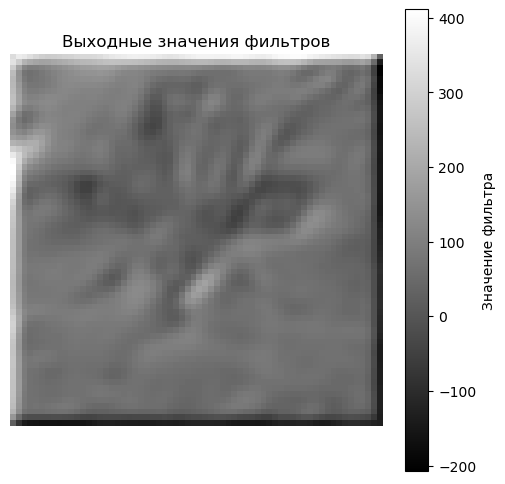

In [12]:
# Нормализация данных для отображения
norm = colors.Normalize(vmin=matrix1.min(), vmax=matrix1.max())

# Создание изображения
plt.figure(figsize=(6, 6))
plt.imshow(matrix1, cmap='gray', norm=norm)
plt.colorbar(label='Значение фильтра')
plt.title('Выходные значения фильтров')
plt.axis('off')  # Скрыть оси
plt.show()

In [13]:
img1 = cv2.imread("1.png",-1) # cv2.IMREAD_UNCHANGED` или -1: изображение "как есть" - со всеми слоями, прозрачностью
print(img1, img1.shape)

[[174 160 172 ... 182 223 244]
 [213 226 184 ... 223 217 154]
 [163 202 194 ... 165 127 135]
 ...
 [137 131 122 ...  99 100 114]
 [136 129 118 ...  85  89 112]
 [132 125 117 ...  73  91 109]] (64, 64)


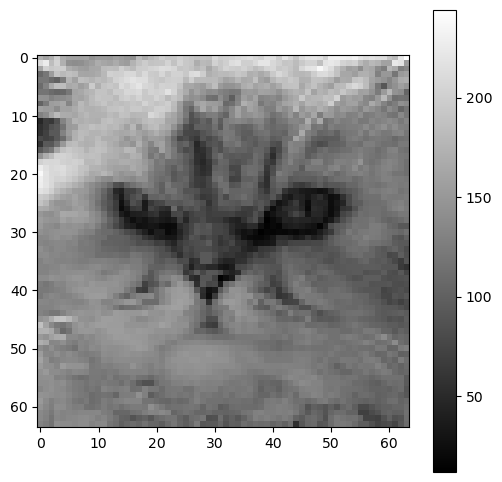

In [17]:
# настройки отображения Matplotlib
plt.rcParams['figure.figsize'] = (6.0, 6.0)
plt.rcParams['image.cmap'] = 'gray'

plt.imshow(img1)
plt.colorbar()

## Решение оптим задачи на всем датасете

### Dataset Dataloader

In [249]:
class FilterDataset(Dataset):
    def __init__(self, orig_dir, out_dir):
        self.orig_files = sorted([f for f in os.listdir(orig_dir) if f.endswith('.png')])
        self.out_files = sorted([f for f in os.listdir(out_dir) if f.endswith('.txt')])
        self.orig_dir = orig_dir
        self.out_dir = out_dir
        
    def __len__(self):
        return len(self.orig_files)
    
    # def __getitem__(self, idx):
    #     # Загрузка и нормализация изображения [0,1]
    #     img = np.array(Image.open(os.path.join(self.orig_dir, self.orig_files[idx])).convert('L'), dtype=np.float32) / 255.0
    #     target = np.loadtxt(os.path.join(self.out_dir, self.out_files[idx]), dtype=np.float32)
    #     return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(target).unsqueeze(0)  # [1,64,64]
    def __getitem__(self, idx):
        # Загрузка изображения без нормализации
        img = np.array(Image.open(os.path.join(self.orig_dir, self.orig_files[idx])).convert('L'), dtype=np.float32)
        target = np.loadtxt(os.path.join(self.out_dir, self.out_files[idx]), dtype=np.float32)
        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(target).unsqueeze(0)  # [1,6

In [250]:
# Инициализация датасета и загрузчика
dataset = FilterDataset('orig_images', 'out_filter_img')

In [251]:
# Получаем первый элемент (индекс 0)
sample_input, sample_target = dataset[0]  # Правильный синтаксис

# Проверяем размерности
print("Размер входного изображения:", sample_input.shape)  # Должно быть torch.Size([1, 64, 64])
print("Размер целевого выхода:", sample_target.shape)     # Должно быть torch.Size([1, 64, 64])

Размер входного изображения: torch.Size([1, 64, 64])
Размер целевого выхода: torch.Size([1, 64, 64])


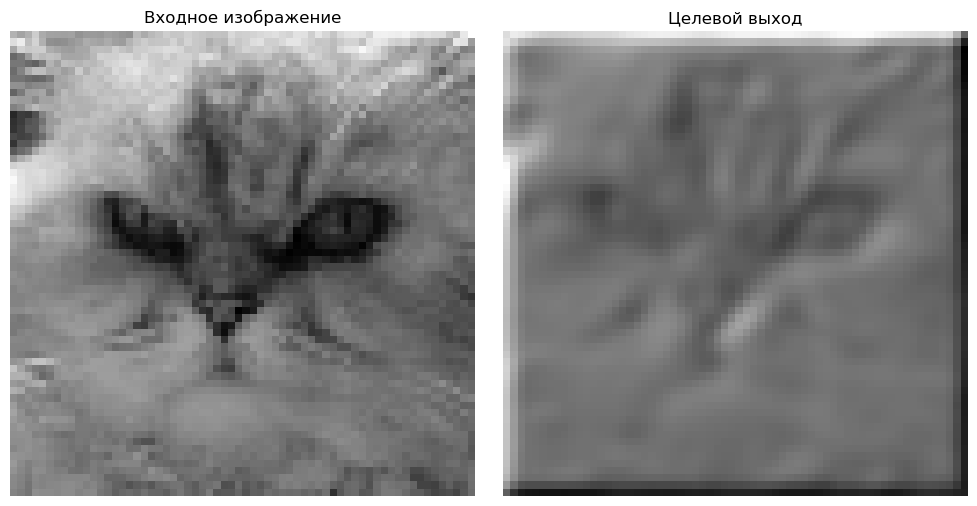

In [169]:
# Визуализируем пример
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_input[0], cmap='gray')  # Убираем размерность канала
plt.title('Входное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_target[0], cmap='gray')
plt.title('Целевой выход')
plt.axis('off')

plt.tight_layout()
plt.show()

In [252]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

### Модель и обучение на всем датасете

In [253]:
class FilterReconstructor(nn.Module):
    def __init__(self):
        super().__init__()
        self.f3 = nn.Parameter(torch.randn(1, 1, 3, 3, dtype=torch.float32))
        nn.init.xavier_uniform_(self.f3)
        
    def forward(self, x, f1, f2):
        # Применяем фильтры в заданной последовательности: f2 -> f3 -> f1
        conv1 = F.conv2d(x, f2, padding=1)    # Первый шаг: фиксированный f2
        conv2 = F.conv2d(conv1, self.f3, padding=1)  # Второй шаг: наш обучаемый f3
        conv3 = F.conv2d(conv2, f1, padding=1)    # Третий шаг: фиксированный f1
        return conv3

In [254]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [256]:
# Фиксированные фильтры
f1 = torch.tensor([[-1.0000, -0.5000, 0.0000],
    [-0.5000, 0.5000, 0.5000],
    [0.0000, 0.5000, 1.0000]]).view(1,1,3,3).to(device)  # Ваш f1
f2 = torch.tensor([[0.0625,	0.0625,	0.0625],
    [0.0625,	0.0625,	0.0625],
    [0.0625,	0.0625,	0.0625]]).view(1,1,3,3).to(device)  # Ваш f2


In [257]:
f1.shape, f2.shape

(torch.Size([1, 1, 3, 3]), torch.Size([1, 1, 3, 3]), torch.Size([1, 1, 3, 3]))

In [210]:
model = FilterReconstructor().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)
criterion = nn.MSELoss()

In [293]:
%%time

best_loss = float('inf')
best_f3 = None
loss_history = []

for epoch in range(100):
    model.train()
    epoch_loss = 0.0
    
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs, f1, f2)
        loss = criterion(outputs, targets)
        loss.backward()
        
        # Градиентный clipping (опционально)
        # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        epoch_loss += loss.item() * inputs.size(0)
    
    epoch_loss /= len(dataset)
    loss_history.append(epoch_loss)
    
    # Сохранение лучшей модели
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_f3 = model.f3.data.clone()
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'best_loss': best_loss,
            'f3': best_f3
        }, 'best_filter.pth')
    
    print(f'Epoch {epoch+1}, Loss: {epoch_loss:.10f}')

Epoch 1, Loss: 0.0000000224
Epoch 2, Loss: 0.0000001054
Epoch 3, Loss: 0.0000007159
Epoch 4, Loss: 0.0000207631
Epoch 5, Loss: 0.0653379519
Epoch 6, Loss: 0.0307087216
Epoch 7, Loss: 0.0056144425
Epoch 8, Loss: 0.0306859451
Epoch 9, Loss: 0.1751955514
Epoch 10, Loss: 0.0757647575
Epoch 11, Loss: 0.0115214732
Epoch 12, Loss: 0.0008881383
Epoch 13, Loss: 0.0000922098
Epoch 14, Loss: 0.0000009645
Epoch 15, Loss: 0.0000002155
Epoch 16, Loss: 0.0000000335
Epoch 17, Loss: 0.0000000496
Epoch 18, Loss: 0.0000000093
Epoch 19, Loss: 0.0000000081
Epoch 20, Loss: 0.0000000070
Epoch 21, Loss: 0.0000000067
Epoch 22, Loss: 0.0000000063
Epoch 23, Loss: 0.0000000066
Epoch 24, Loss: 0.0000000194
Epoch 25, Loss: 0.0000000068
Epoch 26, Loss: 0.0000000085
Epoch 27, Loss: 0.0000023730
Epoch 28, Loss: 0.0004314844
Epoch 29, Loss: 0.1589732564
Epoch 30, Loss: 0.2338397377
Epoch 31, Loss: 0.0033342329
Epoch 32, Loss: 0.0001934349
Epoch 33, Loss: 0.0000237363
Epoch 34, Loss: 0.0000004838
Epoch 35, Loss: 0.00000

In [294]:
# Загрузка лучшей модели (пример)
checkpoint = torch.load('best_filter.pth')
model.load_state_dict(checkpoint['model_state_dict'])
best_f3 = checkpoint['f3']

print(f"\nЛучшая MSE: {best_loss:.10f}")
print("Лучший f3:")
print(best_f3.cpu().numpy()[0,0].round(4))


Лучшая MSE: 0.0000000003
Лучший f3:
[[0.125 0.25  0.125]
 [0.25  0.5   0.25 ]
 [0.125 0.25  0.125]]


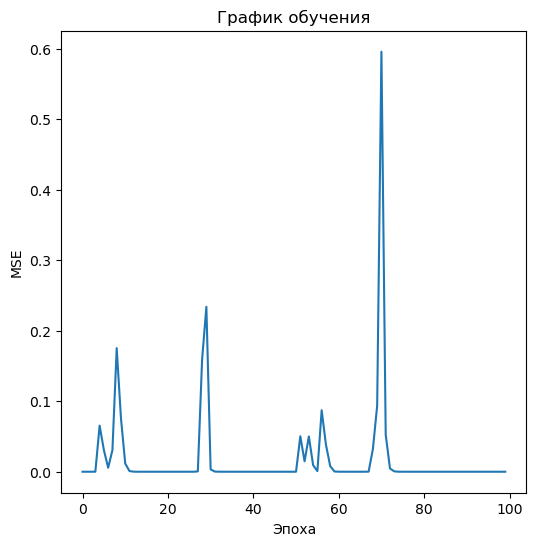

In [295]:
# Визуализация истории обучения
plt.plot(loss_history)
plt.title('График обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.show()

In [299]:
# Валидация на тестовом наборе
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in dataloader:
        outputs = model(inputs.to(device), f1, f2)
        test_loss += criterion(outputs, targets.to(device)).item()
        
print(f"Финальная тестовая ошибка: {test_loss/len(dataloader):.10f}")

Финальная тестовая ошибка: 0.0000000005


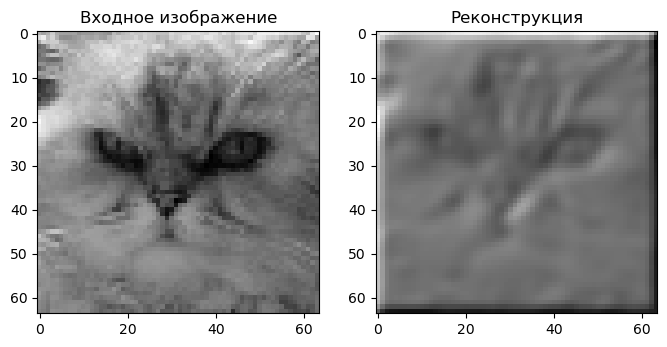

In [264]:
# 2. Правильный вызов модели
sample_input = sample_input.unsqueeze(0).to(device)  # Добавляем размерность батча и переносим на устройство

with torch.no_grad():
    sample_output = model(sample_input, f1, f2).cpu()  # Теперь передаем все 3 аргумента

# 3. Визуализация
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(sample_input[0,0].cpu(), cmap='gray')
plt.title('Входное изображение')

plt.subplot(122)
plt.imshow(sample_output[0,0], cmap='gray')
plt.title('Реконструкция')
plt.show()

## Улучшение модели с комбинир-ем вариантов фильтров

In [172]:
filter_sequences = list(permutations([f1, f2, None]))  # None будет заменен на f3
print("Все возможные последовательности:")
for i, seq in enumerate(filter_sequences):
    print(f"{i+1}. {[f.shape if f is not None else 'f3' for f in seq]}")

Все возможные последовательности:
1. [torch.Size([1, 1, 3, 3]), torch.Size([1, 1, 3, 3]), 'f3']
2. [torch.Size([1, 1, 3, 3]), 'f3', torch.Size([1, 1, 3, 3])]
3. [torch.Size([1, 1, 3, 3]), torch.Size([1, 1, 3, 3]), 'f3']
4. [torch.Size([1, 1, 3, 3]), 'f3', torch.Size([1, 1, 3, 3])]
5. ['f3', torch.Size([1, 1, 3, 3]), torch.Size([1, 1, 3, 3])]
6. ['f3', torch.Size([1, 1, 3, 3]), torch.Size([1, 1, 3, 3])]


In [173]:
class SequenceTester(nn.Module):
    def __init__(self, f3_init):
        super().__init__()
        self.f3 = nn.Parameter(f3_init.clone())
        
    def forward(self, x, sequence):
        out = x
        for filt in sequence:
            if filt is None:  # Это наш обучаемый f3
                out = F.conv2d(out, self.f3, padding=1)
            else:
                out = F.conv2d(out, filt, padding=1)
        return out

In [174]:
best_sequence = None
best_f3 = None
best_loss = float('inf')
results = []

for seq_idx, sequence in enumerate(filter_sequences):
    print(f"\nТестируем последовательность {seq_idx+1}: {sequence}")
    
    # Инициализация модели
    model = SequenceTester(torch.randn(1, 1, 3, 3)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    # optimizer = optim.RMSprop(model.parameters(), lr=0.005)
    # Обучение
    for epoch in range(500):
        epoch_loss = 0
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs, sequence)
            loss = F.mse_loss(outputs, targets)
            # loss = F.mse_loss(outputs, targets) + 0.01*torch.norm(model.f3, p=1)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        if (epoch+1) % 20 == 0:
            print(f"Эпоха {epoch+1}, Loss: {epoch_loss/len(dataloader):.4f}")
    
    # Оценка на всем датасете
    with torch.no_grad():
        total_loss = 0
        for inputs, targets in dataloader:
            outputs = model(inputs.to(device), sequence)
            total_loss += F.mse_loss(outputs, targets.to(device)).item()
        
        avg_loss = total_loss / len(dataloader)
        results.append((sequence, avg_loss, model.f3.data.clone()))
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_sequence = sequence
            best_f3 = model.f3.data.clone()
        
        print(f"Последовательность {seq_idx+1}, Final MSE: {avg_loss:.4f}")


Тестируем последовательность 1: (tensor([[[[-1.0000, -0.5000,  0.0000],
          [-0.5000,  0.5000,  0.5000],
          [ 0.0000,  0.5000,  1.0000]]]]), tensor([[[[0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625]]]]), None)
Эпоха 20, Loss: 7737.6371
Эпоха 40, Loss: 6393.0627
Эпоха 60, Loss: 5356.4770
Эпоха 80, Loss: 4408.0379
Эпоха 100, Loss: 3663.3425
Эпоха 120, Loss: 3008.8009
Эпоха 140, Loss: 2506.8379
Эпоха 160, Loss: 2114.7883
Эпоха 180, Loss: 1818.1862
Эпоха 200, Loss: 1612.4870
Эпоха 220, Loss: 1491.1653
Эпоха 240, Loss: 1420.8645


KeyboardInterrupt: 

In [135]:
# Вывод результатов
print("\nРезультаты:")
for i, (seq, loss, f3) in enumerate(results):
    print(f"{i+1}. Последовательность: {seq}, MSE: {loss:.4f}")

print(f"\nЛучшая последовательность: {best_sequence} с MSE {best_loss:.4f}")
print("Лучший f3:")
print(best_f3.cpu().numpy()[0,0])


Результаты:
1. Последовательность: (tensor([[[[-1.0000, -0.5000,  0.0000],
          [-0.5000,  0.5000,  0.5000],
          [ 0.0000,  0.5000,  1.0000]]]]), tensor([[[[0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625]]]]), None), MSE: 3603.2579
2. Последовательность: (tensor([[[[-1.0000, -0.5000,  0.0000],
          [-0.5000,  0.5000,  0.5000],
          [ 0.0000,  0.5000,  1.0000]]]]), None, tensor([[[[0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625]]]])), MSE: 3618.5773
3. Последовательность: (tensor([[[[0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625]]]]), tensor([[[[-1.0000, -0.5000,  0.0000],
          [-0.5000,  0.5000,  0.5000],
          [ 0.0000,  0.5000,  1.0000]]]]), None), MSE: 2933.5658
4. Последовательность: (tensor([[[[0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625]]]]), None, tensor([

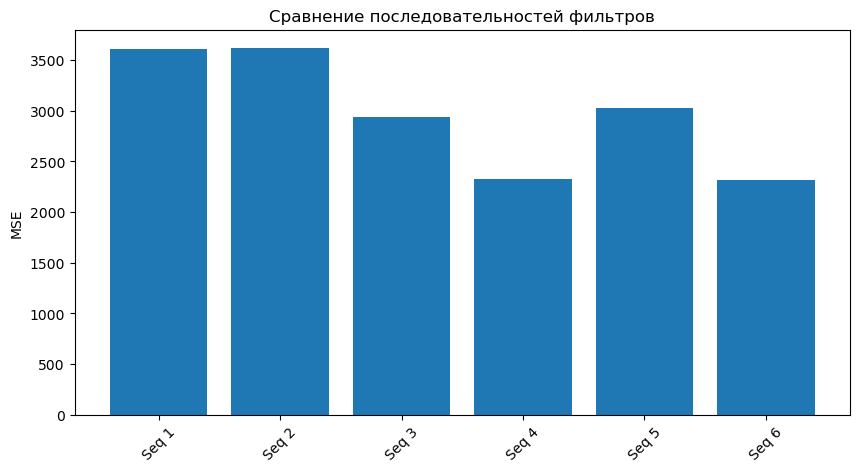

In [134]:
plt.figure(figsize=(10,5))
plt.bar(range(len(results)), [r[1] for r in results])
plt.xticks(range(len(results)), [f"Seq {i+1}" for i in range(len(results))], rotation=45)
plt.ylabel('MSE')
plt.title('Сравнение последовательностей фильтров')
plt.show()

# Задание B

Вскоре после восстановления алгоритмов Kai Asano отдел разведки BlackCircuit получил новую задачу.
В сеть проникли неизвестные генеративные модели-подражатели — их задача: маскироваться под старые работы мастеров цифрового искусства, стирая грань между оригиналом и копией.

Чтобы выявить плагиат и разоблачить их источники, необходимо построить систему поиска похожих кадров. У нас есть архив изображений — часть является оригиналами, часть — подражателями.

Ваша миссия: для каждого изображения из набора найти 6 наиболее похожих кадров.

Данные:

Архив изображений доступен по ссылке.
Каждое изображение одновременно служит и запросом, и кандидатом для рекомендации.
Изображение не может быть рекомендовано само себе.
Название изображения однозначно его определяет.
Для каждого изображения вы должны указать 6 других изображений наиболее похожих на него. Ответ оформляется в .csv формате с двумя столбцами, разделёнными запятой:

filename — имя файла-запроса.
ranking — имена 6 наиболее похожих файлов, разделённые пробелами.
Пример submission.csv:

filename,ranking
0001.png,0010.png 0011.png 0012.png 0013.png 0014.png 0015.png
0002.png,0010.png 0011.png 0012.png 0013.png 0014.png 0015.png
...
Важные условия:

Оценка проводится по совпадению ваших рекомендаций с внутренней системой BlackCircuit: необходимо достичь хотя бы 0.5 совпадений.
Порядок рекомендаций внутри строки не важен.
Внимание: подражатели совершенствуются с каждым циклом. Чем точнее будет ваша система поиска, тем быстрее мы сможем отделить настоящее искусство от копии.

## Модель

ResNet-18 обучалась на 224×224 (ImageNet), но отлично работает и с 256×256 благодаря своей архитектуре. Главное — сохранять нормализацию и учитывать, что признаки были оптимизированы для задач, похожих на ImageNet.

Почему работает на 256×256?
Несмотря на то, что ResNet-18 обучалась на 224×224, она может обрабатывать и другие размеры:

Сверточные слои автоматически адаптируются к размеру входа.

Адаптивный AvgPool перед последним слоем преобразует любой размер в 1×1 (например, 7×7 → 1×1 для 224×224, или 8×8 → 1×1 для 256×256).

Для извлечения признаков (как в вашем ImageEmbedder):

Можно подавать изображения 256×256 — модель корректно обработает их.

Лучше использовать нормализацию и аугментации как в оригинальном обучении:

In [189]:
# Загрузка предобученной модели (например, ResNet без последнего слоя)
class ImageEmbedder(nn.Module):
    def __init__(self):
        super().__init__()
        # self.model = models.resnet18(pretrained=True)
        # self.model = models.resnet50(pretrained=True)
        self.model = models.resnet101(pretrained=True)
        # self.model = models.efficientnet_b4(pretrained=True)
        # self.model = models.vit_b_16(pretrained=True)
        self.model.fc = nn.Identity()  # Удаляем последний слой
        
    def forward(self, x):
        return self.model(x)

In [190]:
model = ImageEmbedder().eval()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:00<00:00, 197MB/s]  


In [191]:
print(model)

ImageEmbedder(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

## Извлечение признаков для всех изображений

In [192]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [193]:
# Путь к папке с изображениями
image_dir = "/kaggle/input/data-img/dataset"
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])

### GPU

In [198]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)  # Перенос модели на GPU

In [46]:
def extract_features(image_path, model):
    img = Image.open(image_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)  # Перенос изображения на GPU
    with torch.no_grad():
        features = model(img)
    return features.squeeze().cpu().numpy()  # Возвращаем на CPU для совместимости с numpy

In [199]:
from torch.utils.data import Dataset, DataLoader

In [195]:
class ImageDataset(Dataset):
    def __init__(self, image_files, transform):
        self.image_files = image_files
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(image_dir, self.image_files[idx])).convert('RGB')
        return self.transform(img)

In [200]:
# Создаем DataLoader с батчами
batch_size = 64  # Можно увеличить для GPU
dataset = ImageDataset(image_files, transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [201]:
%%time
# Извлекаем признаки батчами
features = []
model.eval()
with torch.no_grad():
    for batch in dataloader:
        batch = batch.to(device)
        features_batch = model(batch)
        features.append(features_batch.cpu().numpy())
features = np.concatenate(features, axis=0)

CPU times: user 2min 12s, sys: 976 ms, total: 2min 13s
Wall time: 1min 42s


In [148]:
# 3. Извлечение эмбеддингов для трансформеров
def extract_embeddings(image_files, batch_size=64):
    embeddings = []
    for i in range(0, len(image_files), batch_size):
        batch_files = image_files[i:i+batch_size]
        batch_images = [Image.open(os.path.join(image_dir, f)).convert("RGB") for f in batch_files]
        
        inputs = image_processor(images=batch_images, return_tensors="pt").to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            batch_embeddings = outputs.last_hidden_state[:, 0, :]  # Берем [CLS]-токен
            batch_embeddings = torch.nn.functional.normalize(batch_embeddings, p=2, dim=1)
            embeddings.append(batch_embeddings.cpu().numpy())
    
    return np.concatenate(embeddings, axis=0)

features = extract_embeddings(image_files)

## Поиск ближайших соседей

In [202]:
n_neighbors = 7  # 6 + само изображение

model_nn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
model_nn.fit(features)


NearestNeighbors(metric='cosine', n_neighbors=7)

In [203]:
distances, indices = model_nn.kneighbors(features)

In [204]:
distances.shape

(9605, 7)

In [100]:
# pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 58.3 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [106]:
import faiss
from faiss import IndexFlatIP

In [107]:
# 1. Подготовка данных (предполагается, что features и image_files уже загружены)
features_normalized = features / np.linalg.norm(features, axis=1, keepdims=True)  # Нормализация

# 2. Создание и заполнение индекса Faiss
index = faiss.IndexFlatIP(features.shape[1])  # Индекс для скалярного произведения
index.add(features_normalized.astype('float32'))  # Добавляем все эмбеддинги

# 3. Поиск соседей для КАЖДОГО изображения (включая себя)
k = 7  # 6 соседей + само изображение
D, I = index.search(features_normalized.astype('float32'), k)  # I - матрица индексов

In [177]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
# Нормализация + PCA
features_norm = normalize(features, norm='l2')  # Обязательно!
pca = PCA(n_components=128)
features_pca = pca.fit_transform(features_norm)

In [178]:
# Используйте косинусное расстояние
model_nn = NearestNeighbors(n_neighbors=7, metric='cosine', algorithm='brute')
model_nn.fit(features_pca)

# Для исключения самого изображения
distances, indices = model_nn.kneighbors(features_pca)
neighbor_indices = [idx[1:7] for idx in indices]  # Берем соседей 1-6

## Формирование файла submission.csv

In [205]:
# KNN
results = []

for i, img_file in enumerate(image_files):
    # Берем 6 ближайших (исключая само изображение)
    neighbors = indices[i][1:7]  # пропускаем первый элемент (само изображение)
    neighbor_files = ' '.join([image_files[idx] for idx in neighbors])
    results.append([img_file, neighbor_files])

In [108]:
# FAISS
# 4. Формирование результатов (исключаем само изображение)
results = []
for i, img_file in enumerate(image_files):
    # Берем 6 ближайших, исключая первый результат (само изображение)
    neighbor_indices = I[i][1:7]  # индексы 1-6
    neighbor_files = ' '.join([image_files[idx] for idx in neighbor_indices])
    results.append([img_file, neighbor_files])

In [206]:
# Создаем DataFrame и сохраняем в CSV
df = pd.DataFrame(results, columns=['filename', 'ranking'])

In [207]:
df

,filename,ranking
0,0000.png,8222.png 6448.png 4932.png 8492.png 9405.png 2...
1,0001.png,5029.png 6470.png 5193.png 1149.png 3986.png 3...
2,0002.png,7688.png 3977.png 5492.png 2448.png 1858.png 5...
3,0003.png,6326.png 6438.png 9169.png 5911.png 3675.png 5...
4,0004.png,4593.png 4191.png 6371.png 7238.png 5676.png 1...
...,...,...
9600,9600.png,7663.png 0268.png 9135.png 0896.png 7670.png 2...
9601,9601.png,8581.png 0213.png 3844.png 4463.png 2344.png 0...
9602,9602.png,7691.png 2158.png 5991.png 4789.png 9189.png 6...
9603,9603.png,6298.png 0893.png 6401.png 8022.png 8816.png 1...


In [208]:
df.to_csv('submission_resnet101_knn.csv', index=False)

In [112]:
def display_query_and_neighbors(query_image_path, neighbor_image_paths, images_dir):
    """
    Визуализирует запрос и топ-6 похожих изображений.
    
    Параметры:
        query_image_path (str): Путь к изображению-запросу.
        neighbor_image_paths (list): Список путей к 6 похожим изображениям.
        images_dir (str): Папка с изображениями.
    """
    # Загрузка изображений
    query_img = Image.open(os.path.join(images_dir, query_image_path))
    neighbors_img = [Image.open(os.path.join(images_dir, path)) for path in neighbor_image_paths]
    
    # Создание сетки для отображения
    fig, axes = plt.subplots(1, 7, figsize=(20, 5))
    
    # Отображение запроса
    axes[0].imshow(query_img)
    axes[0].set_title("Запрос\n" + query_image_path, fontsize=8)
    axes[0].axis('off')
    
    # Отображение соседей
    for i, img in enumerate(neighbors_img, 1):
        axes[i].imshow(img)
        axes[i].set_title(f"Сосед {i}\n" + neighbor_image_paths[i-1], fontsize=8)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

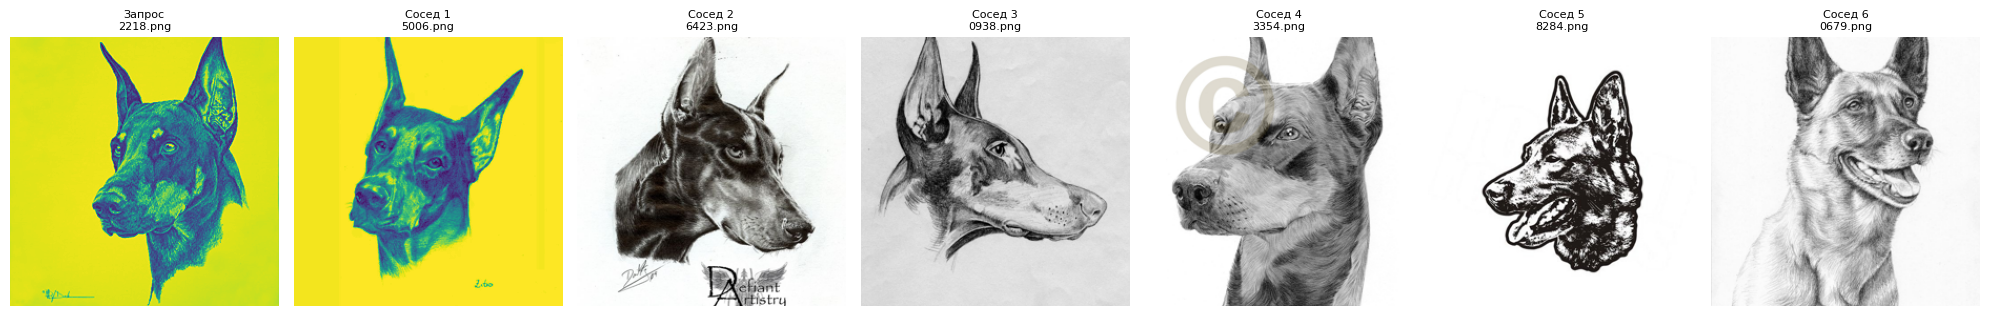

In [252]:
# Пример использования:
# Выбираем случайный запрос из результатов
import random
sample = random.choice(results)
query = sample[0]
neighbors = sample[1].split()  # Разбиваем строку с соседями
# Визуализация
display_query_and_neighbors(query, neighbors, image_dir)